# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV589"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv589')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv589/lv589-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV589,gene_band
0,ZNF324,4.702636,19q13.43
1,B4GALT4,4.679438,3q13.32
2,RNF14,4.375222,5q31.3
3,ZNF18,3.861038,17p12
4,RAI14,3.338601,5p13.2
5,WWTR1,3.322981,3q25.1
6,NUAK1,2.833695,12q23.3
7,ZNF37A,2.618720,10p11.1
8,TRAK2,2.533705,2q33.1
9,TIMM9,2.258211,14q23.1


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 16:20:59,818 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 16:20:59,818 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP033135, SRP055569, SRP021130, SRP066834, SRP057196, SRP042161, SRP014428, SRP060416, SRP013363, SRP064464, SRP050499, SRP063840, SRP017777, SRP059379, SRP015449, SRP051606, SRP018838, SRP012461, SRP058773, SRP055810, SRP043221, SRP055153, SRP058667, SRP057205, SRP010279, SRP050596, SRP052740, SRP059035, SRP003754, SRP038963, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (29 != 30)
  warnings.warn(


In [12]:
lv_data.shape

(5594, 67)

In [13]:
lv_data.head()

cell type  \
project   run                                                  
SRP033135 SRR1032910  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032911  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032912  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032913  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032914  Human Skeletal Muscle Myoblasts (HSMM)   

                     hour post serum-switch debris control well cells in well  \
project   run                                                                   
SRP033135 SRR1032910                      0  FALSE        FALSE             1   
          SRR1032911                      0  FALSE        FALSE             1   
          SRR1032912                      0  FALSE        FALSE             1   
          SRR1032913                      0  FALSE        FALSE             2   
          SRR1032914                      0  FALSE        FALSE             1   

                     library protocol diagnosis disease group tissue Stage  \
project   run                                                                
SRP033135 SRR1032910      Single-cell       NaN           NaN    NaN   NaN   
          SRR1032911      Single-cell       NaN           NaN    NaN   NaN   
          SRR1032912      Single-cell       NaN           NaN    NaN   NaN   
          SRR1032913      Single-cell       NaN           NaN    NaN   NaN   
          SRR1032914      Single-cell       NaN           NaN    NaN   NaN   

                      ... antibody manufacturer   ID  bmi mapki sensitivity  \
project   run         ...                                                     
SRP033135 SRR1032910  ...                   NaN  NaN  NaN               NaN   
          SRR1032911  ...                   NaN  NaN  NaN               NaN   
          SRR1032912  ...                   NaN  NaN  NaN               NaN   
          SRR1032913  ...                   NaN  NaN  NaN               NaN   
          SRR1032914  ...                   NaN  NaN  NaN               NaN   

                     mapki treatment pasaages clip antibody  \
project   run                                                 
SRP033135 SRR1032910             NaN      NaN           NaN   
          SRR1032911             NaN      NaN           NaN   
          SRR1032912             NaN      NaN           NaN   
          SRR1032913             NaN      NaN           NaN   
          SRR1032914             NaN      NaN           NaN   

                     clip antibody vendor clip antibody cat. #     LV589  
project   run                                                             
SRP033135 SRR1032910                  NaN                  NaN  0.040646  
          SRR1032911                  NaN                  NaN  0.014458  
          SRR1032912                  NaN                  NaN  0.034011  
          SRR1032913                  NaN                  NaN -0.016560  
          SRR1032914                  NaN                  NaN  0.019278  

[5 rows x 67 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

hour post serum-switch         0.189034
debris                         0.189034
control well                   0.189034
cells in well                  0.189034
library protocol               0.189034
cell type                      0.022260
diagnosis                      0.019314
disease group                  0.019314
origin                         0.014798
antibodies                     0.014798
genotype                       0.010566
cell line stably expressing    0.009153
par-clip antibody              0.009153
culture medium                 0.009153
clip antibody vendor           0.008944
clip antibody cat. #           0.008944
clip antibody                  0.008944
pasaages                       0.008944
age                            0.006664
c1 chip id                     0.006640
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell type         0.022260
tissue            0.005314
tissue type       0.004068
tissue subtype    0.004068
cell line         0.002006
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell type",
    "tissue",
    "tissue type",
    "tissue subtype",
    "cell line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell type  \
project   run                                                             
SRP033135 SRR1033231             Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1033199             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR2019100                  WI-38 human lung fibroblast cells   
SRP033135 SRR1033243             Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1033252             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR1821586  mixture of U87 human glioma cells and MCF10a h...   
SRP021130 SRR828725                                                 NaN   
SRP066834 SRR2967796                                                NaN   
SRP033135 SRR1033256             Human Skeletal Muscle Myoblasts (HSMM)   
SRP057196 SRR1974915                                    fetal_quiescent   
SRP066834 SRR2967611                                                NaN   
SRP042161 SRR1294540                                       Glioblastoma   
SRP014428 SRR522079          leukocyte from blood of healthy individual   
SRP057196 SRR1974963                                    fetal_quiescent   
SRP055569 SRR1821650                   MCF10a human breast cancer cells   
SRP060416 SRR2088309                       tonsil Innate lymphoid cells   
SRP055569 SRR1821406                             U87 human glioma cells   
SRP057196 SRR1974808                                            neurons   
SRP060416 SRR2088360                       tonsil Innate lymphoid cells   
          SRR2088510                       tonsil Innate lymphoid cells   
          SRR2088168                       tonsil Innate lymphoid cells   
          SRR2088082                       tonsil Innate lymphoid cells   
          SRR2088276                       tonsil Innate lymphoid cells   
SRP042161 SRR1295049                                       Glioblastoma   
SRP055569 SRR1821657                   MCF10a human breast cancer cells   

                                              tissue tissue type  \
project   run                                                      
SRP033135 SRR1033231                             NaN         NaN   
          SRR1033199                             NaN         NaN   
SRP055569 SRR2019100                             NaN         NaN   
SRP033135 SRR1033243                             NaN         NaN   
          SRR1033252                             NaN         NaN   
SRP055569 SRR1821586                             NaN         NaN   
SRP021130 SRR828725   temporal neocortex gray matter         NaN   
SRP066834 SRR2967796                 Fetal neocortex         NaN   
SRP033135 SRR1033256                             NaN         NaN   
SRP057196 SRR1974915                          cortex         NaN   
SRP066834 SRR2967611                 Fetal neocortex         NaN   
SRP042161 SRR1294540                             NaN         NaN   
SRP014428 SRR522079                              NaN         NaN   
SRP057196 SRR1974963                          cortex         NaN   
SRP055569 SRR1821650                             NaN         NaN   
SRP060416 SRR2088309                             NaN         NaN   
SRP055569 SRR1821406                             NaN         NaN   
SRP057196 SRR1974808                          cortex         NaN   
SRP060416 SRR2088360                             NaN         NaN   
          SRR2088510                             NaN         NaN   
          SRR2088168                             NaN         NaN   
          SRR2088082                             NaN         NaN   
          SRR2088276                             NaN         NaN   
SRP042161 SRR1295049                             NaN         NaN   
SRP055569 SRR1821657                             NaN         NaN   

                     tissue subtype cell line     LV589  
project   run                                            
SRP033135 SRR1033231            NaN       NaN  8.339867  
          SRR1033199     

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

cell type  \
project   run                                                             
SRP042161 SRR1294501                                       Glioblastoma   
SRP055569 SRR2019152  mixture of U87 human glioma cells and WI-38 hu...   
          SRR1821645                   MCF10a human breast cancer cells   
SRP057196 SRR1974676                                        endothelial   
SRP055569 SRR1821353                             U87 human glioma cells   
          SRR2019160  mixture of U87 human glioma cells and WI-38 hu...   
SRP033135 SRR1033213             Human Skeletal Muscle Myoblasts (HSMM)   
SRP013363 SRR500486                                                 NaN   
SRP060416 SRR2088710                       tonsil Innate lymphoid cells   
SRP042161 SRR1294650                                       Glioblastoma   
SRP057196 SRR1974986                                    fetal_quiescent   
SRP042161 SRR1294911                                       Glioblastoma   
SRP033135 SRR1033024             Human Skeletal Muscle Myoblasts (HSMM)   
SRP042161 SRR1295284                             Gliomasphere Cell Line   
SRP066834 SRR2967427                                                NaN   
SRP060416 SRR2088574                       tonsil Innate lymphoid cells   
SRP057196 SRR1974620                                            neurons   
SRP042161 SRR1294689                                       Glioblastoma   
          SRR1294791                                       Glioblastoma   
SRP033135 SRR1033210             Human Skeletal Muscle Myoblasts (HSMM)   
SRP060416 SRR2088153                       tonsil Innate lymphoid cells   
SRP033135 SRR1033261             Human Skeletal Muscle Myoblasts (HSMM)   
SRP064464 SRR2558123                                                NaN   
SRP050499 SRR2013740                                                NaN   
SRP060416 SRR2088118                       tonsil Innate lymphoid cells   

                                                   tissue tissue type  \
project   run                                                           
SRP042161 SRR1294501                                  NaN         NaN   
SRP055569 SRR2019152                                  NaN         NaN   
          SRR1821645                                  NaN         NaN   
SRP057196 SRR1974676                               cortex         NaN   
SRP055569 SRR1821353                                  NaN         NaN   
          SRR2019160                                  NaN         NaN   
SRP033135 SRR1033213                                  NaN         NaN   
SRP013363 SRR500486                                   NaN         NaN   
SRP060416 SRR2088710                                  NaN         NaN   
SRP042161 SRR1294650                                  NaN         NaN   
SRP057196 SRR1974986                               cortex         NaN   
SRP042161 SRR1294911                                  NaN         NaN   
SRP033135 SRR1033024                                  NaN         NaN   
SRP042161 SRR1295284                                  NaN         NaN   
SRP066834 SRR2967427  Dissociated whole cerebral organoid         NaN   
SRP060416 SRR2088574                                  NaN         NaN   
SRP057196 SRR1974620                               cortex         NaN   
SRP042161 SRR1294689                                  NaN         NaN   
          SRR1294791                                  NaN         NaN   
SRP033135 SRR1033210                                  NaN         NaN   
SRP060416 SRR2088153                                  NaN         NaN   
SRP033135 SRR1033261                                  NaN         NaN   
SRP064464 SRR2558123                                  NaN         NaN   
SRP050499 SRR2013740                                  NaN         NaN   
SRP060416 SRR2088118                                  NaN         NaN   

                     tissue subtype cell line     LV589  
projec

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "cell type",
    "tissue",
    "tissue type",
    "tissue subtype",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

cell type  \
project   run                                                             
SRP033135 SRR1033231             Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1033199             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR2019100                  WI-38 human lung fibroblast cells   
SRP033135 SRR1033243             Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1033252             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR1821586  mixture of U87 human glioma cells and MCF10a h...   
SRP021130 SRR828725                      temporal neocortex gray matter   
SRP066834 SRR2967796                                    Fetal neocortex   
SRP033135 SRR1033256             Human Skeletal Muscle Myoblasts (HSMM)   
SRP057196 SRR1974915                                    fetal_quiescent   
SRP066834 SRR2967611                                    Fetal neocortex   
SRP042161 SRR1294540                                       Glioblastoma   
SRP014428 SRR522079          leukocyte from blood of healthy individual   
SRP057196 SRR1974963                                    fetal_quiescent   
SRP055569 SRR1821650                   MCF10a human breast cancer cells   
SRP060416 SRR2088309                       tonsil Innate lymphoid cells   
SRP055569 SRR1821406                             U87 human glioma cells   
SRP057196 SRR1974808                                            neurons   
SRP060416 SRR2088360                       tonsil Innate lymphoid cells   
          SRR2088510                       tonsil Innate lymphoid cells   

                         LV589  
project   run                   
SRP033135 SRR1033231  8.339867  
          SRR1033199  0.907618  
SRP055569 SRR2019100  0.782129  
SRP033135 SRR1033243  0.781402  
          SRR1033252  0.617131  
SRP055569 SRR1821586  0.612547  
SRP021130 SRR828725   0.599953  
SRP066834 SRR2967796  0.520833  
SRP033135 SRR1033256  0.491064  
SRP057196 SRR1974915  0.484284  
SRP066834 SRR2967611  0.471966  
SRP042161 SRR1294540  0.471228  
SRP014428 SRR522079   0.460180  
SRP057196 SRR1974963  0.418403  
SRP055569 SRR1821650  0.397489  
SRP060416 SRR2088309  0.391901  
SRP055569 SRR1821406  0.378289  
SRP057196 SRR1974808  0.374367  
SRP060416 SRR2088360  0.373619  
          SRR2088510  0.369619

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['Human Skeletal Muscle Myoblasts (HSMM)',
 'WI-38 human lung fibroblast cells',
 'mixture of U87 human glioma cells and MCF10a human breast cancer cells',
 'temporal neocortex gray matter',
 'Fetal neocortex']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

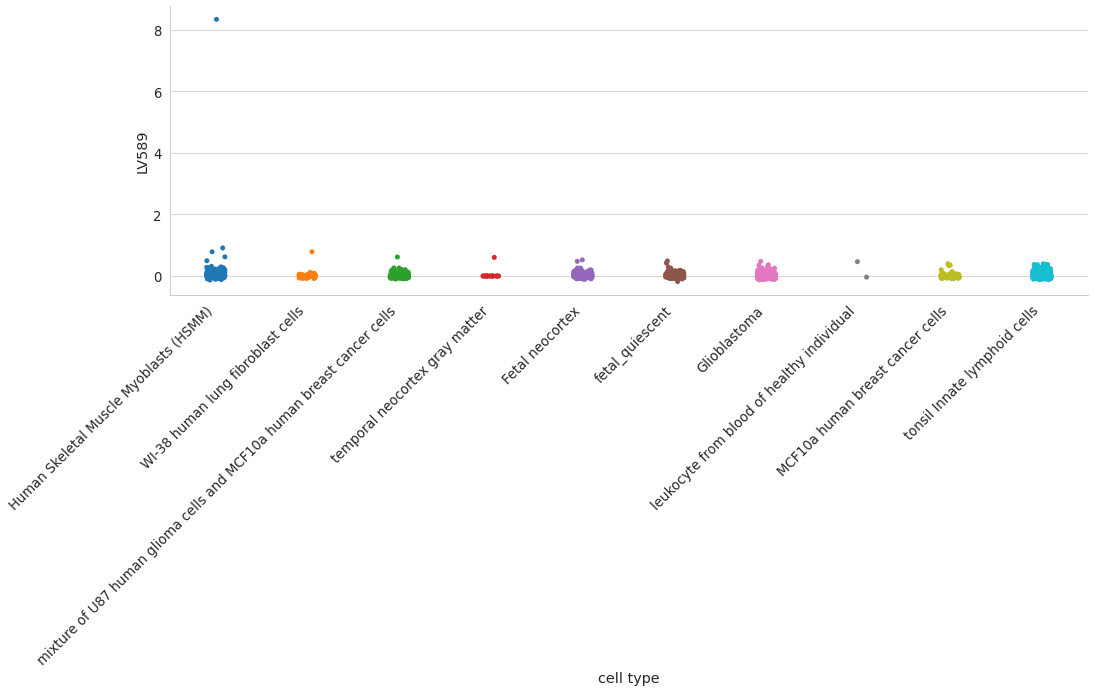

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Mesenc")
    ]
    display(_tmp.head(20))

cell type     LV582
project   run                                        
SRP012461 SRR490308  Mesenchymal Stem Cells  0.431175
          SRR490311  Mesenchymal Stem Cells  0.109218
          SRR490229  Mesenchymal Stem Cells  0.106094
          SRR490280  Mesenchymal Stem Cells  0.060764
          SRR490231  Mesenchymal Stem Cells  0.055113
          SRR490226  Mesenchymal Stem Cells  0.047083
          SRR490245  Mesenchymal Stem Cells  0.038019
          SRR490327  Mesenchymal Stem Cells  0.035258
          SRR490305  Mesenchymal Stem Cells  0.033120
          SRR490338  Mesenchymal Stem Cells  0.032719
          SRR490336  Mesenchymal Stem Cells  0.031067
          SRR490337  Mesenchymal Stem Cells  0.030776
          SRR490284  Mesenchymal Stem Cells  0.030576
          SRR490331  Mesenchymal Stem Cells  0.030554
          SRR490339  Mesenchymal Stem Cells  0.028162
          SRR490333  Mesenchymal Stem Cells  0.027978
          SRR490220  Mesenchymal Stem Cells  0.027498
          SRR490296  Mesenchymal Stem Cells  0.027087
          SRR490328  Mesenchymal Stem Cells  0.027043
          SRR490290  Mesenchymal Stem Cells  0.026657

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP012461, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP012461"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell type       treatment day  \
project   run                                                     
SRP012461 SRR490465             Fibroblasts    Osteogenesis  d3   
          SRR490467             Fibroblasts    Osteogenesis  d3   
          SRR490464             Fibroblasts    Osteogenesis  d3   
          SRR490466             Fibroblasts    Osteogenesis  d3   
          SRR490308  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490311  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490229  Mesenchymal Stem Cells    Adipogenesis  d3   
          SRR490280  Mesenchymal Stem Cells    Osteogenesis  d1   
          SRR490231  Mesenchymal Stem Cells    Adipogenesis  d3   
          SRR490425             Fibroblasts    Adipogenesis  d7   
          SRR490456             Fibroblasts      Noninduced  d0   
          SRR490226  Mesenchymal Stem Cells    Adipogenesis  d2   
          SRR490449             Fibroblasts    Adipogenesis  d5   
          SRR490459             Fibroblasts      Noninduced  d0   
          SRR490452             Fibroblasts    Adipogenesis  d7   
          SRR490458             Fibroblasts      Noninduced  d0   
          SRR490514             Fibroblasts    Osteogenesis  d7   
          SRR490446             Fibroblasts    Adipogenesis  d4   
          SRR490571             Fibroblasts  Chondrogenesis  d5   
          SRR490511             Fibroblasts    Osteogenesis  d6   
          SRR490522             Fibroblasts  Chondrogenesis  d1   
          SRR490512             Fibroblasts    Osteogenesis  d7   
          SRR490427             Fibroblasts    Adipogenesis  d7   
          SRR490523             Fibroblasts  Chondrogenesis  d1   
          SRR490421             Fibroblasts    Adipogenesis  d6   
          SRR490517             Fibroblasts      Noninduced  d0   
          SRR490429             Fibroblasts      Noninduced  d0   
          SRR490509             Fibroblasts    Osteogenesis  d6   
          SRR490245  Mesenchymal Stem Cells      Noninduced  d0   
          SRR490510             Fibroblasts    Osteogenesis  d6   
          SRR490445             Fibroblasts    Adipogenesis  d4   
          SRR490444             Fibroblasts    Adipogenesis  d4   
          SRR490327  Mesenchymal Stem Cells    Osteogenesis  d4   
          SRR490515             Fibroblasts    Osteogenesis  d7   
          SRR490447             Fibroblasts    Adipogenesis  d4   
          SRR490520             Fibroblasts  Chondrogenesis  d1   
          SRR490428             Fibroblasts      Noninduced  d0   
          SRR490418             Fibroblasts    Adipogenesis  d5   
          SRR490305  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490419             Fibroblasts    Adipogenesis  d5   
          SRR490485             Fibroblasts      Noninduced  d0   
          SRR490338  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490513             Fibroblasts    Osteogenesis  d7   
          SRR490499             Fibroblasts    Osteogenesis  d3   
          SRR490541             Fibroblasts  Chondrogenesis  d6   
          SRR490491             Fibroblasts    Osteogenesis  d1   
          SRR490497             Fibroblasts    Osteogenesis  d3   
          SRR490336  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490508             Fibroblasts    Osteogenesis  d6   
          SRR490337  Mesenchymal Stem Cells    Osteogenesis  d7   
          SRR490519             Fibroblasts      Noninduced  d0   
          SRR490524             Fibroblasts  Chondrogenesis  d2   
          SRR490284  Mesenchymal Stem Cells    Osteogenesis  d2   
          SRR490457             Fibroblasts      Noninduced  d0   
          SRR490331  Mesenchymal Stem Cells    Osteogenesis  d5   
          SRR490516             Fibroblasts      Noninduced  d0   
          SRR490417             Fibroblasts    Adipogenesis  d5   
          SRR490498             Fibroblasts    Osteogenesis  d3   
          SRR4

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.